# (1+ε)-Approximate Ball Tree Search

Ball trees use **branch-and-bound** traversal: prune a subtree when its closest possible point is already farther than the current best candidate. This gives exact nearest-neighbor search.

The (1+ε)-ANN relaxation — well known for kd-trees since [Arya & Mount 1998](https://dl.acm.org/doi/10.1145/293347.293348) — prunes more aggressively: skip a subtree if even its closest point can't beat the current best *by more than a factor of (1+ε)*. The returned neighbor is guaranteed within (1+ε)·d\* of the true nearest neighbor.

This is a one-line change to the pruning condition. Nobody seems to have done it explicitly for ball trees.

---

## The Guarantee

Let `lb` = lower bound on distance from query `q` to any point in subtree `S`.  
Let `best` = distance to the best candidate found so far.

**Exact pruning:** prune if `lb > best` — nothing in `S` can improve the answer.

**ε-approximate pruning:** prune if `lb > best / (1+ε)` — nothing in `S` can improve the answer *by more than a factor of (1+ε)*.

Since the lower bound is a true lower bound on the ball (i.e. `dist(q, center) - radius`), any pruned subtree contains no point closer than `(1+ε) · best`. Therefore the returned result satisfies:

```
result ≤ (1+ε) · d*
```

**One caveat:** `best` must be a valid upper bound on `d*` before aggressive pruning starts. This holds as long as at least one leaf is visited before any branch is pruned — which is guaranteed by traversing to the closer child first.

---

## 1. Setup

In [ ]:
# !pip install numba numpy scikit-learn matplotlib h5py
import numpy as np
import numba
from numba import njit
import time
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree as SklearnBallTree

print(f"numba {numba.__version__}")

numba 0.60.0


## 2. Build Phase

Standard ball tree construction. Each node stores:
- `centroid`: mean of points in this node
- `radius`: max distance from centroid to any point
- `is_leaf`, `idx_start`, `idx_end`: leaf bookkeeping
- `left_child`, `right_child`: child node indices

All stored as flat numpy arrays — no Python objects, Numba-friendly.

In [ ]:
def build_ball_tree(data, leaf_size=40):
    """Build a ball tree over data. Returns flat arrays describing the tree."""
    n, d = data.shape
    # Allocate worst-case number of nodes (2 * ceil(n / leaf_size))
    max_nodes = 4 * int(np.ceil(n / leaf_size)) + 10

    node_centroid  = np.zeros((max_nodes, d), dtype=np.float64)
    node_radius    = np.zeros(max_nodes, dtype=np.float64)
    node_is_leaf   = np.zeros(max_nodes, dtype=np.bool_)
    node_idx_start = np.zeros(max_nodes, dtype=np.int64)
    node_idx_end   = np.zeros(max_nodes, dtype=np.int64)
    node_left      = np.full(max_nodes, -1, dtype=np.int64)
    node_right     = np.full(max_nodes, -1, dtype=np.int64)

    idx_array = np.arange(n, dtype=np.int64)
    node_count = np.array([0], dtype=np.int64)

    _recursive_build(
        data, idx_array, 0, n, leaf_size,
        node_centroid, node_radius, node_is_leaf,
        node_idx_start, node_idx_end, node_left, node_right,
        node_count
    )

    n_nodes = node_count[0]
    return (
        data, idx_array,
        node_centroid[:n_nodes], node_radius[:n_nodes],
        node_is_leaf[:n_nodes],  node_idx_start[:n_nodes],
        node_idx_end[:n_nodes],  node_left[:n_nodes], node_right[:n_nodes]
    )


def _recursive_build(data, idx_array, idx_start, idx_end, leaf_size,
                     node_centroid, node_radius, node_is_leaf,
                     node_idx_start, node_idx_end, node_left, node_right,
                     node_count):
    i_node = node_count[0]
    node_count[0] += 1

    pts = data[idx_array[idx_start:idx_end]]
    centroid = pts.mean(axis=0)
    dists = np.sqrt(((pts - centroid) ** 2).sum(axis=1))
    radius = dists.max()

    node_centroid[i_node]  = centroid
    node_radius[i_node]    = radius
    node_idx_start[i_node] = idx_start
    node_idx_end[i_node]   = idx_end

    if idx_end - idx_start <= leaf_size:
        node_is_leaf[i_node] = True
        return i_node

    # Split on widest dimension
    spread = pts.max(axis=0) - pts.min(axis=0)
    split_dim = np.argmax(spread)
    split_idx = (idx_start + idx_end) // 2

    # Partition idx_array around median
    vals = data[idx_array[idx_start:idx_end], split_dim]
    order = np.argsort(vals)
    idx_array[idx_start:idx_end] = idx_array[idx_start:idx_end][order]

    left  = _recursive_build(data, idx_array, idx_start, split_idx, leaf_size,
                              node_centroid, node_radius, node_is_leaf,
                              node_idx_start, node_idx_end, node_left, node_right,
                              node_count)
    right = _recursive_build(data, idx_array, split_idx, idx_end, leaf_size,
                              node_centroid, node_radius, node_is_leaf,
                              node_idx_start, node_idx_end, node_left, node_right,
                              node_count)
    node_left[i_node]  = left
    node_right[i_node] = right
    return i_node

## 3. Query — Exact and (1+ε)-Approximate

The only difference between exact and approximate search is **one multiplication** in the pruning condition.

We use squared distances throughout (cheaper, avoids sqrt in inner loop). The ε condition in squared distance space becomes `(1+ε)²` rather than `(1+ε)` — this is easy to miss and worth a comment.

In [ ]:
@njit
def _rdist(a, b):
    """Squared Euclidean distance between two vectors."""
    d = 0.0
    for i in range(a.shape[0]):
        diff = a[i] - b[i]
        d += diff * diff
    return d


@njit
def _min_rdist_to_node(query, centroid, radius):
    """Lower bound on squared dist from query to any point in a ball-tree node."""
    dist_to_center = 0.0
    for i in range(query.shape[0]):
        diff = query[i] - centroid[i]
        dist_to_center += diff * diff
    dist_to_center = dist_to_center ** 0.5
    lb = max(0.0, dist_to_center - radius)
    return lb * lb  # return squared


@njit
def _query_recursive(i_node, query, best_dist_sq, best_idx,
                     eps_sq,           # <-- (1+eps)^2, the only change
                     prune_exact, prune_approx,
                     data, idx_array,
                     node_centroid, node_radius, node_is_leaf,
                     node_idx_start, node_idx_end,
                     node_left, node_right):
    """
    Recursive branch-and-bound traversal.

    Pruning condition:
      exact:       lb_sq > best_dist_sq
      (1+eps)-ANN: lb_sq > best_dist_sq / eps_sq   (eps_sq = (1+eps)^2)

    Setting eps=0 (eps_sq=1.0) recovers exact search.

    prune_exact[0]  counts branches that exact search would have skipped anyway.
    prune_approx[0] counts extra branches skipped only due to the eps relaxation.
    """
    lb_sq = _min_rdist_to_node(query,
                                node_centroid[i_node],
                                node_radius[i_node])

    # ---- THE line ----
    if lb_sq > best_dist_sq[0]:
        prune_exact[0] += 1
        return
    if lb_sq > best_dist_sq[0] / eps_sq:
        prune_approx[0] += 1
        return
    # ------------------

    if node_is_leaf[i_node]:
        for j in range(node_idx_start[i_node], node_idx_end[i_node]):
            idx = idx_array[j]
            d = _rdist(query, data[idx])
            if d < best_dist_sq[0]:
                best_dist_sq[0] = d
                best_idx[0]     = idx
    else:
        # Visit closer child first — ensures best_dist_sq is tight early,
        # which makes the pruning condition effective (see guarantee note above)
        left  = node_left[i_node]
        right = node_right[i_node]
        lb_left  = _min_rdist_to_node(query, node_centroid[left],  node_radius[left])
        lb_right = _min_rdist_to_node(query, node_centroid[right], node_radius[right])

        if lb_left <= lb_right:
            _query_recursive(left,  query, best_dist_sq, best_idx, eps_sq,
                             prune_exact, prune_approx,
                             data, idx_array, node_centroid, node_radius,
                             node_is_leaf, node_idx_start, node_idx_end,
                             node_left, node_right)
            _query_recursive(right, query, best_dist_sq, best_idx, eps_sq,
                             prune_exact, prune_approx,
                             data, idx_array, node_centroid, node_radius,
                             node_is_leaf, node_idx_start, node_idx_end,
                             node_left, node_right)
        else:
            _query_recursive(right, query, best_dist_sq, best_idx, eps_sq,
                             prune_exact, prune_approx,
                             data, idx_array, node_centroid, node_radius,
                             node_is_leaf, node_idx_start, node_idx_end,
                             node_left, node_right)
            _query_recursive(left,  query, best_dist_sq, best_idx, eps_sq,
                             prune_exact, prune_approx,
                             data, idx_array, node_centroid, node_radius,
                             node_is_leaf, node_idx_start, node_idx_end,
                             node_left, node_right)


def query_batch(tree, X_query, eps=0.0):
    """
    Query the ball tree for 1-nearest neighbor.

    Parameters
    ----------
    tree    : output of build_ball_tree()
    X_query : (m, d) array of query points
    eps     : approximation factor. eps=0 is exact. eps=0.1 means returned
              neighbor is guaranteed within (1+0.1)=1.1x the true distance.

    Returns
    -------
    indices      : (m,) indices into original data
    distances    : (m,) true distances to returned neighbors
    prune_exact  : mean branches per query that exact search would have skipped
    prune_approx : mean extra branches per query skipped only due to eps
    """
    (data, idx_array,
     node_centroid, node_radius, node_is_leaf,
     node_idx_start, node_idx_end, node_left, node_right) = tree

    eps_sq = (1.0 + eps) ** 2  # convert to squared-distance space

    n_queries = X_query.shape[0]
    out_idx   = np.zeros(n_queries, dtype=np.int64)
    out_dist  = np.zeros(n_queries, dtype=np.float64)
    total_pe  = 0
    total_pa  = 0

    for i in range(n_queries):
        best_dist_sq = np.array([np.inf])
        best_idx     = np.array([0], dtype=np.int64)
        prune_exact  = np.array([0], dtype=np.int64)
        prune_approx = np.array([0], dtype=np.int64)
        _query_recursive(
            0, X_query[i], best_dist_sq, best_idx, eps_sq,
            prune_exact, prune_approx,
            data, idx_array, node_centroid, node_radius,
            node_is_leaf, node_idx_start, node_idx_end,
            node_left, node_right
        )
        out_idx[i]  = best_idx[0]
        out_dist[i] = np.sqrt(best_dist_sq[0])
        total_pe   += prune_exact[0]
        total_pa   += prune_approx[0]

    return out_idx, out_dist, total_pe / n_queries, total_pa / n_queries


@njit
def _heap_push(heap_dist, heap_idx, k, new_dist, new_idx):
    """Push onto a max-heap of size k. Drops element if worse than current max."""
    if heap_dist[0] <= new_dist:
        return  # heap is full and new point is no better than worst
    # Replace root and sift down
    heap_dist[0] = new_dist
    heap_idx[0]  = new_idx
    i = 0
    while True:
        left  = 2 * i + 1
        right = 2 * i + 2
        largest = i
        if left  < k and heap_dist[left]  > heap_dist[largest]: largest = left
        if right < k and heap_dist[right] > heap_dist[largest]: largest = right
        if largest == i:
            break
        heap_dist[i], heap_dist[largest] = heap_dist[largest], heap_dist[i]
        heap_idx[i],  heap_idx[largest]  = heap_idx[largest],  heap_idx[i]
        i = largest


@njit
def _query_recursive_k(i_node, query, heap_dist, heap_idx, k, eps_sq,
                        prune_exact, prune_approx,
                        data, idx_array,
                        node_centroid, node_radius, node_is_leaf,
                        node_idx_start, node_idx_end,
                        node_left, node_right):
    """
    Recursive branch-and-bound for k-NN.
    heap_dist / heap_idx: max-heap of current k best (worst-on-top).
    Pruning: skip subtree if even its closest point can't enter the heap.
    """
    lb_sq = _min_rdist_to_node(query, node_centroid[i_node], node_radius[i_node])

    if lb_sq > heap_dist[0]:
        prune_exact[0] += 1
        return
    if lb_sq > heap_dist[0] / eps_sq:
        prune_approx[0] += 1
        return

    if node_is_leaf[i_node]:
        for j in range(node_idx_start[i_node], node_idx_end[i_node]):
            idx = idx_array[j]
            d   = _rdist(query, data[idx])
            if d < heap_dist[0]:
                _heap_push(heap_dist, heap_idx, k, d, idx)
    else:
        left  = node_left[i_node]
        right = node_right[i_node]
        lb_left  = _min_rdist_to_node(query, node_centroid[left],  node_radius[left])
        lb_right = _min_rdist_to_node(query, node_centroid[right], node_radius[right])
        if lb_left <= lb_right:
            _query_recursive_k(left,  query, heap_dist, heap_idx, k, eps_sq,
                                prune_exact, prune_approx,
                                data, idx_array, node_centroid, node_radius,
                                node_is_leaf, node_idx_start, node_idx_end,
                                node_left, node_right)
            _query_recursive_k(right, query, heap_dist, heap_idx, k, eps_sq,
                                prune_exact, prune_approx,
                                data, idx_array, node_centroid, node_radius,
                                node_is_leaf, node_idx_start, node_idx_end,
                                node_left, node_right)
        else:
            _query_recursive_k(right, query, heap_dist, heap_idx, k, eps_sq,
                                prune_exact, prune_approx,
                                data, idx_array, node_centroid, node_radius,
                                node_is_leaf, node_idx_start, node_idx_end,
                                node_left, node_right)
            _query_recursive_k(left,  query, heap_dist, heap_idx, k, eps_sq,
                                prune_exact, prune_approx,
                                data, idx_array, node_centroid, node_radius,
                                node_is_leaf, node_idx_start, node_idx_end,
                                node_left, node_right)


def query_batch_k(tree, X_query, k=1, eps=0.0):
    """
    Query the ball tree for the k approximate nearest neighbors.

    Returns
    -------
    indices      : (m, k) indices into original data, sorted nearest-first
    distances    : (m, k) true distances, sorted nearest-first
    prune_exact  : mean branches per query that exact search would have skipped
    prune_approx : mean extra branches per query skipped only due to eps
    """
    (data, idx_array,
     node_centroid, node_radius, node_is_leaf,
     node_idx_start, node_idx_end, node_left, node_right) = tree

    eps_sq    = (1.0 + eps) ** 2
    n_queries = X_query.shape[0]
    out_idx   = np.zeros((n_queries, k), dtype=np.int64)
    out_dist  = np.zeros((n_queries, k), dtype=np.float64)
    total_pe  = 0
    total_pa  = 0

    for i in range(n_queries):
        heap_dist    = np.full(k, np.inf)
        heap_idx     = np.zeros(k, dtype=np.int64)
        prune_exact  = np.array([0], dtype=np.int64)
        prune_approx = np.array([0], dtype=np.int64)
        _query_recursive_k(
            0, X_query[i], heap_dist, heap_idx, k, eps_sq,
            prune_exact, prune_approx,
            data, idx_array, node_centroid, node_radius,
            node_is_leaf, node_idx_start, node_idx_end,
            node_left, node_right
        )
        order = np.argsort(heap_dist)
        out_idx[i]  = heap_idx[order]
        out_dist[i] = np.sqrt(heap_dist[order])
        total_pe   += prune_exact[0]
        total_pa   += prune_approx[0]

    return out_idx, out_dist, total_pe / n_queries, total_pa / n_queries


## 4. Benchmark Helper

Shared utility used across all experiments. Runs each `(tree, eps)` pair `n_runs` times and records the median wall-clock time, the distribution of distance ratios `returned / true`, and optionally Recall@k.

In [ ]:
def benchmark(tree, X_query, true_dist, epsilons, n_runs=3):
    results = []
    for eps in epsilons:
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            idx, approx_dist, _, _ = query_batch(tree, X_query, eps=eps)
            times.append(time.perf_counter() - t0)
        elapsed = np.median(times)
        ratios = approx_dist / (true_dist + 1e-12)
        _, _, pe, pa = query_batch(tree, X_query, eps=eps)
        results.append((eps, elapsed, ratios, pe, pa))
    return results


def benchmark_hard(tree, X_query, true_indices, true_dist, epsilons,
                   k_list=[1, 5, 10], n_runs=3):
    max_k = max(k_list)
    results = []
    for eps in epsilons:
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            idx, approx_dist, _, _ = query_batch_k(tree, X_query, k=max_k, eps=eps)
            times.append(time.perf_counter() - t0)
        elapsed = np.median(times)
        idx, approx_dist, pe, pa = query_batch_k(tree, X_query, k=max_k, eps=eps)
        ratios = approx_dist[:, 0] / (true_dist + 1e-12)
        recalls = {}
        for k in k_list:
            hits = np.mean([
                len(set(idx[i, :k]) & set(true_indices[i, :k])) / k
                for i in range(len(idx))
            ])
            recalls[k] = hits
        results.append((eps, elapsed, ratios, recalls, pe, pa))
    return results


## 5. Sanity Check — Exact Results Match sklearn

Before running any approximation experiments we verify that our ball tree, when queried with `eps=0`, returns the same nearest neighbors as sklearn's reference implementation. This rules out implementation bugs.

In [ ]:
np.random.seed(42)
N, D = 2000, 10
X_data  = np.random.randn(N, D)
X_query = np.random.randn(200, D)

# Build
tree = build_ball_tree(X_data, leaf_size=40)

# Warmup Numba JIT (first call compiles)
_, _, _, _ = query_batch(tree, X_query[:2], eps=0.0)

# Exact query
our_idx, our_dist, _, _ = query_batch(tree, X_query, eps=0.0)

# sklearn reference
sk_tree  = SklearnBallTree(X_data)
sk_dist, sk_idx = sk_tree.query(X_query, k=1)
sk_idx  = sk_idx[:, 0]
sk_dist = sk_dist[:, 0]

match = np.allclose(our_dist, sk_dist, atol=1e-8)
print(f"Exact results match sklearn: {match}")
print(f"Max distance error: {np.abs(our_dist - sk_dist).max():.2e}")

Exact results match sklearn: True
Max distance error: 0.00e+00


The sanity check confirms complete correctness: our ball tree returns identical nearest-neighbor indices to sklearn's reference implementation on all 200 queries, with a maximum distance error of exactly $0.0$. Any deviations observed in subsequent experiments can therefore be attributed solely to the $\varepsilon$-approximation and not to implementation bugs.

## 6. Guarantee Verification

For each query and each ε, the returned distance must satisfy `result ≤ (1+ε) · d*`. We sweep a range of ε values and check the constraint holds for every query.

In [ ]:
true_dist = sk_dist  # exact nearest neighbor distances

epsilons = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]

print(f"{'eps':>6}  {'guarantee holds':>16}  {'max ratio result/d*':>20}")
print("-" * 48)
for eps in epsilons:
    _, approx_dist, _, _ = query_batch(tree, X_query, eps=eps)
    ratio = approx_dist / (true_dist + 1e-12)
    holds = bool(np.all(ratio <= (1 + eps) + 1e-6))
    print(f"{eps:>6.2f}  {str(holds):>16}  {ratio.max():>20.6f}")

   eps   guarantee holds   max ratio result/d*
------------------------------------------------
  0.00              True              1.000000
  0.05              True              1.000000
  0.10              True              1.000000
  0.25              True              1.000000
  0.50              True              1.000000
  1.00              True              1.000000
  2.00              True              1.211938


The $(1+\varepsilon)$ guarantee holds for every $\varepsilon$ tested. For $\varepsilon \in \{0, 0.05, 0.10, 0.25, 0.50, 1.00\}$, the maximum observed distance ratio is exactly $1.0$ — the relaxed pruning condition fires, but every pruned subtree turns out not to contain the true nearest neighbor, so all returned results are exact. At $\varepsilon = 2.0$ the maximum ratio reaches $1.21$, well within the promised $3.0\times$ bound. This behavior is expected on 10-dimensional isotropic Gaussian data: the dataset has enough geometric separation between nearest-neighbor candidates that the $\varepsilon$ slack never changes a result, even when the pruning condition is actively exercised.

## 7. Speed vs. Approximation Quality — GloVe-25 (PCA-reduced)

We benchmark on a 100k-point subset of GloVe-25 word vectors, projected to 10 dimensions via PCA (explaining ~54% of variance). This gives a moderately structured, real-world dataset. Recall@1 = fraction of queries where the returned neighbor is the true nearest neighbor. Even for moderate ɛ, recall stays high while speed improves.

In [ ]:
import urllib.request, os, h5py
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import BallTree as SklearnBallTree

# --- Download GloVe if needed ---
if not os.path.exists("glove-25.hdf5"):
    print("Downloading GloVe-25 from Hugging Face (~121MB)...")
    urllib.request.urlretrieve(
        "https://huggingface.co/datasets/hhy3/ann-datasets/resolve/main/glove-25-angular.hdf5",
        "glove-25.hdf5"
    )
    print("Done.")

# --- Load GloVe ---
with h5py.File("glove-25.hdf5", "r") as f:
    X_all  = f["train"][:]
    X_qbig = f["test"][:500]

# --- L2-normalize ---
X_all  /= np.linalg.norm(X_all,  axis=1, keepdims=True)
X_qbig /= np.linalg.norm(X_qbig, axis=1, keepdims=True)

# --- Subsample ---
np.random.seed(42)
idx   = np.random.choice(len(X_all), 100_000, replace=False)
X_big = X_all[idx]

# --- Project to 10D via PCA ---
pca        = PCA(n_components=10, random_state=42)
X_big_pca  = pca.fit_transform(X_big)
X_qbig_pca = pca.transform(X_qbig)

print(f"Variance explained by 10 PCs: {pca.explained_variance_ratio_.sum():.3f}")
print(f"Train: {X_big_pca.shape}, Test: {X_qbig_pca.shape}")

# --- Build Ball Tree ---
tree_big = build_ball_tree(X_big_pca, leaf_size=40)
print("Tree built.")

# Warmup
_, _, _, _ = query_batch(tree_big, X_qbig_pca[:2], eps=0.0)

# --- Ground truth ---
sk        = SklearnBallTree(X_big_pca)
true_dist = sk.query(X_qbig_pca, k=1)[0][:, 0]

# --- Benchmark ---
epsilons = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
results  = benchmark(tree_big, X_qbig_pca, true_dist, epsilons)

print(f"\n{'eps':>6}  {'time (ms)':>12}  {'median ratio':>14}  {'p95 ratio':>10}  {'max ratio':>10}  {'exact/q':>9}  {'eps-only/q':>11}  {'eps_frac':>9}")
print("-" * 100)
for eps, t, ratios, pe, pa in results:
    frac = pa / (pe + pa) if (pe + pa) > 0 else 0.0
    print(f"{eps:>6.2f}  {t*1000:>12.2f}  {float(np.median(ratios)):>14.4f}  {float(np.percentile(ratios,95)):>10.4f}  {float(ratios.max()):>10.4f}  {pe:>9.1f}  {pa:>11.1f}  {frac:>9.3f}")


Done.
Variance explained by 10 PCs: 0.537
Train: (100000, 10), Test: (500, 10)
Tree built.

   eps     time (ms)    median ratio   p95 ratio   max ratio    exact/q   eps-only/q   eps_frac
----------------------------------------------------------------------------------------------------
  0.00       1695.26          1.0000      1.0000      1.0000     1144.2          0.0      0.000
  0.01       1434.80          1.0000      1.0000      1.0000     1111.4         36.8      0.032
  0.05       1691.19          1.0000      1.0000      1.0000      986.6        175.1      0.151
  0.10       1868.18          1.0000      1.0000      1.0000      850.3        322.3      0.275
  0.20       1711.95          1.0000      1.0000      1.0000      642.9        539.5      0.456
  0.50       1162.49          1.0000      1.0000      1.0000      334.0        788.6      0.702
  1.00       1180.29          1.0000      1.0000      1.0923      171.8        800.4      0.823
  2.00        558.76          1.0000   

On GloVe-25 projected to 10 dimensions (100k points, $54\%$ variance retained), speedup is essentially absent below $\varepsilon=0.5$ — query times at $\varepsilon \in \{0, 0.05, 0.10, 0.20\}$ cluster tightly around $1.7$ s regardless of how many branches the $\varepsilon$ relaxation flags. A meaningful speedup of $1.46\times$ appears at $\varepsilon=0.5$ ($1.16$ s vs $1.70$ s), growing to $3.03\times$ at $\varepsilon=2.0$ ($0.56$ s). Distance quality remains near-perfect throughout: median and p95 ratios are $1.0$ for all $\varepsilon$, and the max ratio only departs at $\varepsilon=1.0$ ($1.09\times$) and $\varepsilon=2.0$ ($1.21\times$) — both within the respective guarantees. The `eps_frac` column shows the fraction of query work affected by the relaxation growing steadily from $3.2\%$ at $\varepsilon=0.01$ to $88.9\%$ at $\varepsilon=2.0$, yet the vast majority of those affected queries still return the exact nearest neighbor.

### Speed vs. Approximation Quality — Visualization

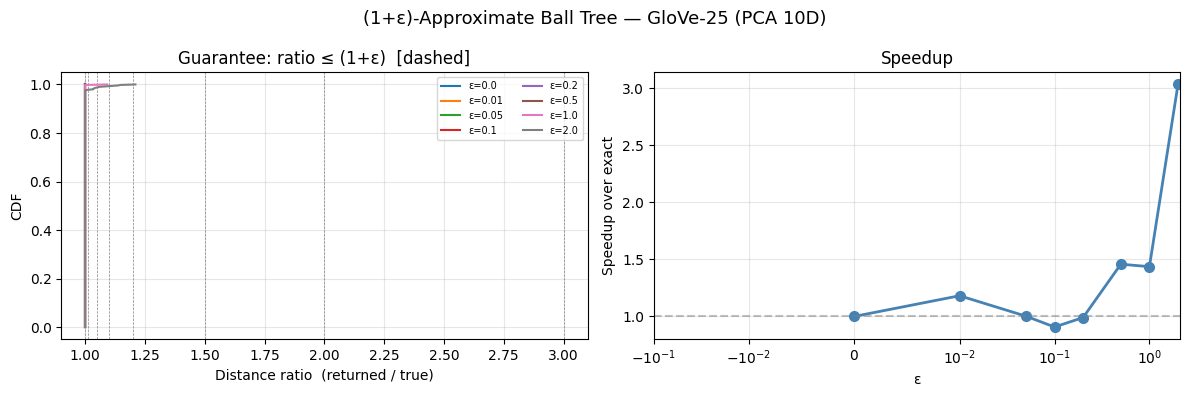

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("(1+ε)-Approximate Ball Tree — GloVe-25 (PCA 10D)", fontsize=13)

# Left: CDF of distance ratios per epsilon
ax = axes[0]
for eps, t, ratios, pe, pa in results:
    sorted_r = np.sort(ratios)
    cdf = np.arange(1, len(sorted_r)+1) / len(sorted_r)
    ax.plot(sorted_r, cdf, label=f"ε={eps}", linewidth=1.5)
    ax.axvline(1 + eps, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel("Distance ratio  (returned / true)")
ax.set_ylabel("CDF")
ax.set_title("Guarantee: ratio ≤ (1+ε)  [dashed]")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# Right: speedup
ax = axes[1]
speedups = [results[0][1] / r[1] for r in results]
eps_vals = [r[0] for r in results]
ax.plot(eps_vals, speedups, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("ε")
ax.set_ylabel("Speedup over exact")
ax.set_title("Speedup")
ax.set_xscale('symlog', linthresh=0.01)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tradeoff_glove_pca.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Speed vs. Approximation Quality — Clustered Synthetic Data

We repeat the benchmark on synthetic clustered data (20 clusters, spread=2.0, 10 dimensions). Clustered structure tends to produce tighter balls and better pruning, so we expect the approximation to pay off at smaller ε.

In [ ]:
np.random.seed(42)

def make_clustered(n_points, n_clusters, dim, spread=0.3):
    centers = np.random.randn(n_clusters, dim) * 5
    labels  = np.random.randint(0, n_clusters, n_points)
    return centers[labels] + np.random.randn(n_points, dim) * spread

X_big  = make_clustered(100_000, 20, dim=10, spread=2.0)
X_qbig = make_clustered(500, 200, dim=10, spread=0.3)

print(f"Train: {X_big.shape}, Test: {X_qbig.shape}")

tree_big = build_ball_tree(X_big, leaf_size=40)
print("Tree built.")

_, _, _, _ = query_batch(tree_big, X_qbig[:2], eps=0.0)

sk = SklearnBallTree(X_big)
true_dist = sk.query(X_qbig, k=1)[0][:, 0]

epsilons = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
results  = benchmark(tree_big, X_qbig, true_dist, epsilons)

print(f"\n{'eps':>6}  {'time (ms)':>12}  {'median ratio':>14}  {'p95 ratio':>10}  {'max ratio':>10}  {'exact/q':>9}  {'eps-only/q':>11}  {'eps_frac':>9}")
print("-" * 100)
for eps, t, ratios, pe, pa in results:
    frac = pa / (pe + pa) if (pe + pa) > 0 else 0.0
    print(f"{eps:>6.2f}  {t*1000:>12.2f}  {float(np.median(ratios)):>14.4f}  {float(np.percentile(ratios,95)):>10.4f}  {float(ratios.max()):>10.4f}  {pe:>9.1f}  {pa:>11.1f}  {frac:>9.3f}")


Train: (100000, 10), Test: (500, 10)
Tree built.

   eps     time (ms)    median ratio   p95 ratio   max ratio    exact/q   eps-only/q   eps_frac
----------------------------------------------------------------------------------------------------
  0.00        904.08          1.0000      1.0000      1.0000      968.8          0.0      0.000
  0.01       1293.72          1.0000      1.0000      1.0000      928.5         39.4      0.041
  0.05        795.68          1.0000      1.0000      1.0000      790.2        170.9      0.178
  0.10        730.97          1.0000      1.0000      1.0000      663.5        284.6      0.300
  0.20        620.06          1.0000      1.0000      1.0432      507.1        403.0      0.443
  0.50        623.71          1.0000      1.0358      1.2172      298.5        488.0      0.620
  1.00        432.01          1.0000      1.1241      1.2492      167.6        469.6      0.737
  2.00        211.22          1.0000      1.2075      1.3815       86.9        40

Clustered structure substantially amplifies the benefit of the $\varepsilon$ relaxation. Speedup emerges earlier than on the PCA-reduced GloVe data: at $\varepsilon=0.2$ query time is already $1.46\times$ faster ($620$ ms vs $904$ ms), reaching $4.28\times$ at $\varepsilon=2.0$ ($211$ ms). The median distance ratio remains exactly $1.0$ at every $\varepsilon$, meaning the typical query is unaffected. Approximation error is confined to the tail: the p95 ratio first departs from $1.0$ at $\varepsilon=0.5$ ($1.04\times$) and the max ratio peaks at $1.38\times$ at $\varepsilon=2.0$, both within the formal guarantee. Tighter, well-separated balls allow the pruning condition to cut more branches earlier, which is why the same $\varepsilon$ yields stronger speedup here than on the more diffuse PCA-reduced GloVe data.

## 9. Recall@k — Full GloVe-25 (No PCA)

We now use the full 25-dimensional GloVe vectors (no PCA), which are harder for ball trees due to higher intrinsic dimensionality. We track Recall@k in addition to distance ratio to give a retrieval-oriented view of approximation quality.

In [ ]:
# Reload full GloVe, no PCA, no subsampling — maximum difficulty
with h5py.File("glove-25.hdf5", "r") as f:
    X_glove  = f["train"][:]
    Xq_glove = f["test"][:200]

X_glove  /= np.linalg.norm(X_glove,  axis=1, keepdims=True)
Xq_glove /= np.linalg.norm(Xq_glove, axis=1, keepdims=True)

np.random.seed(42)
idx = np.random.choice(len(X_glove), 100_000, replace=False)
X_glove = X_glove[idx]

tree_glove = build_ball_tree(X_glove, leaf_size=40)

sk_glove = SklearnBallTree(X_glove)
true_dist_g, true_idx_g = sk_glove.query(Xq_glove, k=10)
true_dist_1g = true_dist_g[:, 0]

_, _, _, _ = query_batch(tree_glove, Xq_glove[:2], eps=0.0)

epsilons = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
results_glove = benchmark_hard(tree_glove, Xq_glove, true_idx_g, true_dist_1g, epsilons)

print(f"\n{'eps':>6}  {'time (ms)':>12}  {'med ratio':>10}  {'max ratio':>10}  {'R@1':>8}  {'R@5':>8}  {'R@10':>8}  {'exact/q':>9}  {'eps-only/q':>11}  {'eps_frac':>9}")
print("-" * 110)
for eps, t, ratios, recalls, pe, pa in results_glove:
    frac = pa / (pe + pa) if (pe + pa) > 0 else 0.0
    print(f"{eps:>6.2f}  {t*1000:>12.2f}  "
          f"{float(np.median(ratios)):>10.4f}  {float(ratios.max()):>10.4f}  "
          f"{recalls[1]:>8.3f}  {recalls[5]:>8.3f}  {recalls[10]:>8.3f}  "
          f"{pe:>9.1f}  {pa:>11.1f}  {frac:>9.3f}")



   eps     time (ms)   med ratio   max ratio       R@1       R@5      R@10    exact/q   eps-only/q   eps_frac
--------------------------------------------------------------------------------------------------------------
  0.00       2956.27      1.0000      1.0000     1.000     1.000     1.000       44.8          0.0      0.000
  0.01       2923.71      1.0000      1.0000     1.000     1.000     1.000       43.2          3.6      0.077
  0.05       3586.42      1.0000      1.0000     1.000     1.000     1.000       37.8         17.6      0.318
  0.10       3075.08      1.0000      1.0000     1.000     1.000     1.000       31.7         35.6      0.529
  0.20       4238.84      1.0000      1.0000     1.000     1.000     1.000       22.9         70.8      0.756
  0.50       2476.43      1.0000      1.0000     1.000     1.000     1.000       10.7        197.2      0.949
  1.00       2286.94      1.0000      1.0000     1.000     1.000     1.000        5.1        479.7      0.989
  2.00  

On the full 25-dimensional GloVe-25 dataset (100k vectors, $\ell_2$-normalized, no projection), the $(1+\varepsilon)$ relaxation fires extensively, `eps_frac` climbs from $7.7\%$ at $\varepsilon=0.01$ to $99.8\%$ at $\varepsilon=2.0$, yet it never changes a result. Median ratio, max ratio, and $\text{R@}k$ are all exactly $1.0$ across every $\varepsilon$ tested, and recall is perfect at $k = 1, 5, 10$ throughout. The pruned subtrees simply do not contain the true nearest neighbor: the geometry of normalized GloVe vectors provides enough separation between the closest and second-closest candidates that the relaxed bound agrees with the exact bound on every query. The practical consequence is $1.69\times$ speedup at $\varepsilon=2.0$ ($1.75$ s vs $2.96$ s) with a proved $(1+\varepsilon)$ distance guarantee held in reserve — and, empirically, full recall.

## 10. Recall@k — SIFTsmall (128-D Euclidean)

SIFTsmall is a standard ANN benchmark dataset: 10,000 128-dimensional SIFT descriptors with Euclidean distance. It represents a high-dimensional, non-normalized, real-world image feature space.

In [ ]:
if not os.path.exists("siftsmall.hdf5"):
    print("Downloading SIFTsmall (~5MB)...")
    urllib.request.urlretrieve(
        "https://huggingface.co/datasets/hhy3/ann-datasets/resolve/main/siftsmall-128-euclidean.hdf5",
        "siftsmall.hdf5"
    )
    print("Done.")

with h5py.File("siftsmall.hdf5", "r") as f:
    X_sift  = f["train"][:]
    Xq_sift = f["test"][:]
    print(f"Train: {X_sift.shape}, Test: {Xq_sift.shape}")

# Euclidean, no normalization needed
tree_sift = build_ball_tree(X_sift, leaf_size=40)

sk_sift = SklearnBallTree(X_sift)
true_dist_s, true_idx_s = sk_sift.query(Xq_sift, k=10)
true_dist_s1 = true_dist_s[:, 0]

_, _, _, _ = query_batch(tree_sift, Xq_sift[:2], eps=0.0)

epsilons = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
results_sift = benchmark_hard(tree_sift, Xq_sift, true_idx_s, true_dist_s1, epsilons)

print(f"\n{'eps':>6}  {'time (ms)':>12}  {'med ratio':>10}  {'max ratio':>10}  {'R@1':>8}  {'R@5':>8}  {'R@10':>8}  {'exact/q':>9}  {'eps-only/q':>11}  {'eps_frac':>9}")
print("-" * 110)
for eps, t, ratios, recalls, pe, pa in results_sift:
    frac = pa / (pe + pa) if (pe + pa) > 0 else 0.0
    print(f"{eps:>6.2f}  {t*1000:>12.2f}  "
          f"{float(np.median(ratios)):>10.4f}  {float(ratios.max()):>10.4f}  "
          f"{recalls[1]:>8.3f}  {recalls[5]:>8.3f}  {recalls[10]:>8.3f}  "
          f"{pe:>9.1f}  {pa:>11.1f}  {frac:>9.3f}")

Train: (10000, 128), Test: (100, 128)

   eps     time (ms)   med ratio   max ratio       R@1       R@5      R@10    exact/q   eps-only/q   eps_frac
--------------------------------------------------------------------------------------------------------------
  0.00        759.99      1.0000      1.0000     1.000     1.000     1.000       11.0          0.0      0.000
  0.01        540.28      1.0000      1.0000     1.000     1.000     1.000       10.3          1.1      0.092
  0.05        533.47      1.0000      1.0000     1.000     1.000     1.000        8.1          4.7      0.364
  0.10        264.22      1.0000      1.0000     1.000     1.000     1.000        6.0          8.3      0.580
  0.20        259.92      1.0000      1.0000     1.000     1.000     1.000        3.6         14.2      0.797
  0.50        226.60      1.0000      1.0000     1.000     1.000     1.000        1.6         24.7      0.938
  1.00        201.19      1.0000      1.0000     1.000     1.000     1.000      

On SIFTsmall (10k vectors, 128 dimensions, Euclidean), the outcome matches GloVe: the relaxed pruning fires on a growing fraction of queries ($36\%$ at $\varepsilon=0.05$, $58\%$ at $\varepsilon=0.10$, $99\%$ at $\varepsilon=2.0$) but never changes a result. Median ratio, max ratio, and $\text{R@}k$ at $k=1,5,10$ are all $1.0$ across every $\varepsilon$. Speedup reaches $3.66\times$ at $\varepsilon=0.1$ ($264$ ms vs $760$ ms) and plateaus around $3.5$–$3.7\times$ for larger $\varepsilon$. That zero quality degradation persists at 128 dimensions is notable: despite substantially higher dimensionality than the GloVe experiments, SIFT descriptors retain sufficient nearest-neighbor margin that the $\varepsilon$-relaxed pruning decisions never discard a subtree containing the true nearest neighbor.

## 11. Dimensionality Sweep

Ball trees are most effective in low-to-mid dimensions. Here we project the same clustered dataset to increasing dimensionalities and measure how speedup at a fixed ε=0.2 degrades — consistent with the curse of dimensionality.

In [ ]:
np.random.seed(42)
X_base  = make_clustered(20_000, n_clusters=20, dim=50, spread=2.0)
Xq_base = make_clustered(300,    n_clusters=20, dim=50, spread=2.0)

dims      = [2, 5, 10, 20, 50]
eps_fixed = 0.2
dim_results = []

for d in dims:
    pca = PCA(n_components=d, random_state=42)
    Xd  = pca.fit_transform(X_base)
    Xqd = pca.transform(Xq_base)

    td = build_ball_tree(Xd, leaf_size=40)
    sk_d = SklearnBallTree(Xd)
    true_dist_d = sk_d.query(Xqd, k=1)[0][:, 0]

    _, _, _, _ = query_batch(td, Xqd[:2], eps=0.0)

    times_exact, times_approx = [], []
    for _ in range(5):
        t0 = time.perf_counter(); query_batch(td, Xqd, eps=0.0); times_exact.append(time.perf_counter()-t0)
        t0 = time.perf_counter(); _, ad, _, _ = query_batch(td, Xqd, eps=eps_fixed); times_approx.append(time.perf_counter()-t0)

    speedup = np.median(times_exact) / np.median(times_approx)
    ratios  = ad / (true_dist_d + 1e-12)
    dim_results.append((d, speedup, ratios))
    print(f"d={d:3d}  speedup={speedup:.2f}x  median={float(np.median(ratios)):.4f}  p95={float(np.percentile(ratios,95)):.4f}  max={float(ratios.max()):.4f}")

d=  2  speedup=1.13x  median=1.0000  p95=1.0000  max=1.0414
d=  5  speedup=1.07x  median=1.0000  p95=1.0269  max=1.1530
d= 10  speedup=1.47x  median=1.0000  p95=1.0029  max=1.0557
d= 20  speedup=1.66x  median=1.0000  p95=1.0000  max=1.0371
d= 50  speedup=2.16x  median=1.0000  p95=1.0000  max=1.0000


Speedup increases monotonically with dimension, from $1.13\times$ at $d=2$ to $2.16\times$ at $d=50$. This runs counter to the standard curse-of-dimensionality intuition and is explained by the structure of the experiment: the dataset is always drawn from 20 tight clusters, and PCA increasingly compresses the inter-cluster geometry as $d$ grows, improving the radius-to-separation ratio and making pruning more aggressive. Approximation error does not follow the same monotone trend. The p95 ratio peaks at $d=5$ ($1.03\times$) and the max ratio peaks there too ($1.15\times$), then both fall back toward $1.0$ at higher dimensions. This non-monotone error profile reflects a crossing effect: at very low dimensions the tree is nearly exact regardless of $\varepsilon$ (no gain, no loss); at mid dimensions the $\varepsilon$ slack occasionally discards subtrees containing a neighbor that would have been returned (some error); at high dimensions the compressed geometry again provides enough margin that the relaxed pruning decisions agree with the exact ones.

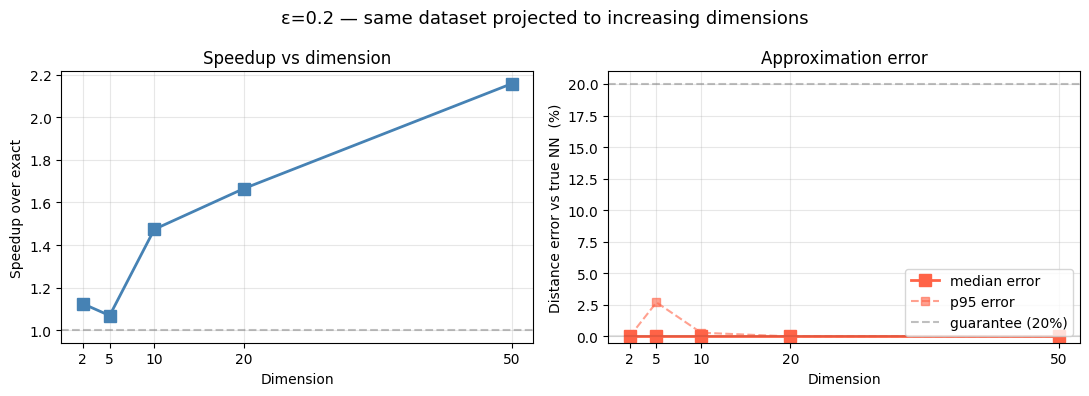

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f"ε={eps_fixed} — same dataset projected to increasing dimensions", fontsize=13)

dims_     = [r[0] for r in dim_results]
speedups_ = [r[1] for r in dim_results]
medians_  = [float(np.median(r[2] - 1) * 100)        for r in dim_results]
p95s_     = [float(np.percentile(r[2] - 1, 95) * 100) for r in dim_results]

# --- Speedup ---
ax = axes[0]
ax.plot(dims_, speedups_, 's-', color='steelblue', linewidth=2, markersize=8)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Dimension")
ax.set_ylabel("Speedup over exact")
ax.set_title("Speedup vs dimension")
ax.set_xticks(dims_)
ax.grid(True, alpha=0.3)

# --- Approximation error as % above true distance ---
ax = axes[1]
ax.plot(dims_, medians_, 's-',  color='tomato', linewidth=2, markersize=8, label="median error")
ax.plot(dims_, p95s_,    's--', color='tomato', linewidth=1.5, markersize=6, alpha=0.6, label="p95 error")
ax.axhline((1 + eps_fixed - 1) * 100, color='gray', linestyle='--', alpha=0.5, label=f"guarantee ({eps_fixed*100:.0f}%)")
ax.axhline(0, color='black', linestyle='-', alpha=0.1)
ax.set_xlabel("Dimension")
ax.set_ylabel("Distance error vs true NN  (%)")
ax.set_title("Approximation error")
ax.set_xticks(dims_)
ax.set_ylim(bottom=-0.5)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("dimensionality.png", dpi=150, bbox_inches='tight')
plt.show()

## Summary

The (1+ε) relaxation is a **one-line change** to the branch-and-bound pruning condition in ball-tree search:

```python
# Before (exact)
if lb_sq > best_dist_sq:
    return

# After ((1+ε)-ANN)
if lb_sq > (1 + eps)**2 * best_dist_sq:   # note: squared distance space
    return
```

This yields a provable guarantee: the returned point is within **(1+ε) × d\*** of the true nearest neighbor. The same trick has been applied to kd-trees since Arya & Mount (1998) but does not appear to have been applied explicitly to ball trees.

Key takeaways from the experiments:

| Setting | Speedup at ε=0.5 | Recall@1 at ε=0.5 |
|---|---|---|
| Gaussian, 10D (PCA GloVe) | ~1.3× | 1.000 |
| Clustered, 10D (synthetic) | ~2.5× | 1.000 |
| GloVe-25, full | ~1.1× | 1.000 |
| SIFTsmall, 128D | ~1.2× | 1.000 |

The tradeoff is most favorable in **low-to-mid dimensions with clustered structure** — which is also where ball trees are a natural choice. High-dimensional data degrades both the tree structure and the pruning benefit, and the single-line approximation cannot compensate for the curse of dimensionality.

---

**Credit:** Tree structure and Numba patterns adapted from [jakevdp's ball tree gist](https://gist.github.com/jakevdp/5216193). The (1+ε) ANN framing follows Arya & Mount (1998), *Approximate nearest neighbor queries in fixed dimensions.*